# 03 — Computing radiative quantities with Smart-G

This notebook shows how to use the individual Smart-G samplers and the convenience `RadiativePipeline` to compute the six radiative quantities needed for TOA simulation.

| Variable | Symbol | Sampler |
|---|---|---|
| Direct downward transmittance | $T_{dir\downarrow}$ | `SmartgSampler_Tdir_down` |
| Direct upward transmittance | $T_{dir\uparrow}$ | `SmartgSampler_Tdir_up` |
| Diffuse downward transmittance | $T_{dif\downarrow}$ | `SmartgSampler_Tdif_down` |
| Diffuse upward transmittance | $T_{dif\uparrow}$ | `SmartgSampler_Tdif_up` |
| Atmospheric path reflectance | $\rho_{atm}$ | `SmartgSampler_Rho_atm` |
| Spherical albedo | $s$ | `SmartgSampler_Sph_alb` |

**Requires:** a configured `SMARTG_DIR_AUXDATA` environment variable and a GPU.

In [1]:
import os
import structlog
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from adjeff.atmosphere import AtmoConfig, GeoConfig, SpectralConfig
from adjeff.core import ImageDict, S2Band
from adjeff.modules.samplers import (
    RadiativePipeline,
    SmartgSampler_Tdir_down,
    SmartgSampler_Tdir_up,
    SmartgSampler_Rho_atm,
    SmartgSampler_Sph_alb,
)

# Verify Smart-G is configured
assert "SMARTG_DIR_AUXDATA" in os.environ, (
    "Set SMARTG_DIR_AUXDATA to the Smart-G auxiliary data directory."
)

# Disable logging
structlog.configure(
    processors=[
        structlog.processors.KeyValueRenderer(key_order=["event"]),
    ],
    logger_factory=structlog.PrintLoggerFactory(file=open("/dev/null", "w")),
)

## 3.1 — Single atmospheric state

The simplest case: one value per parameter, all results are scalars (per band per wavelength).

In [2]:
BANDS = [S2Band.B02, S2Band.B03, S2Band.B04]

atmo = AtmoConfig(
    aot=xr.DataArray([0.1], dims=["aot"]),
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([50.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)

geo = GeoConfig(
    sza=xr.DataArray([30.0], dims=["sza"]),
    vza=xr.DataArray([10.0], dims=["vza"]),
    saa=xr.DataArray([120.0], dims=["saa"]),
    vaa=xr.DataArray([120.0], dims=["vaa"]),
)

spectral = SpectralConfig.from_bands(BANDS)
scene = ImageDict({band: xr.Dataset() for band in BANDS})

# Run the full radiative pipeline
pipeline = RadiativePipeline(
    atmo_config=atmo,
    geo_config=geo,
    spectral_config=spectral,
    remove_rayleigh=False,
)
scene = pipeline(scene)
print(scene)

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=60000000.0), Label(value='')), layout=Layout(align_items='center', …

...

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=90000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=60000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
ImageDict(
  S2Band.B02(490.0nm): ['tdir_down', 'tdir_up', 'sph_alb', 'tdif_up', 'tdif_down', 'rho_atm']
  S2Band.B03(560.0nm): ['tdir_down', 'tdir_up', 'sph_alb', 'tdif_up', 'tdif_down', 'rho_atm']
  S2Band.B04(665.0nm): ['tdir_down', 'tdir_up', 'sph_alb', 'tdif_up', 'tdif_down', 'rho_atm']
)


In [3]:
# Inspect results for B02
ds = scene[S2Band.B02]
print("Variables computed:")
for var in ds.data_vars:
    da = ds[var]
    print(f"  {var:12s}  dims={list(da.dims)}  value={float(da.squeeze()):.5f}")

Variables computed:
  tdir_down     dims=['aot', 'rh', 'href', 'h', 'sza']  value=0.72989
  tdir_up       dims=['aot', 'rh', 'href', 'h', 'vza']  value=0.75814
  sph_alb       dims=['aot', 'rh', 'href', 'h']  value=0.14675
  tdif_up       dims=['vza', 'aot', 'rh', 'href', 'h']  value=0.15957
  tdif_down     dims=['sza', 'aot', 'rh', 'href', 'h']  value=0.17590
  rho_atm       dims=['vza', 'sza', 'aot', 'rh', 'href', 'h']  value=0.06188


The resulting dataset contains data variables `tdir_down`, `tdir_up`, `sph_alb`, `tdif_up`, `tdif_down` and `rho_atm` with single value dimensions. The resulting values must be squeezed in order to be displayed as floats. This design choice was made to keep track of each input parameters used for the computation.

For instance, if another module further use the value of `tdir_down` for an operation, for instance multiplying with an input image of dimensions `(x, y)`, the input image will automatically be broadcasted in the `aot`, `rh`, etc. axes, resulting in an images with dimensions ``(x, y, aot, rh, href, h, sza)`.

## 3.2 — AOT sweep across multiple bands

Let's now sweep over different AOT values. 

In [4]:
aot_values = np.array([0.02, 0.05, 0.10, 0.20, 0.40, 0.80])

atmo_sweep = AtmoConfig(
    aot=xr.DataArray(aot_values, dims=["aot"]),
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([50.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)

pipeline_sweep = RadiativePipeline(
    atmo_config=atmo_sweep,
    geo_config=geo,
    spectral_config=spectral,
    remove_rayleigh=False,
)
scene_sweep = pipeline_sweep(ImageDict({band: xr.Dataset() for band in BANDS}))

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=360000000.0), Label(value='')), layout=Layout(align_items='center',…

...

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=540000000.0), Label(value='')), layout=Layout(align_items='center',…

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=360000000.0), Label(value='')), layout=Layout(align_items='center',…

There is no current context to clear.


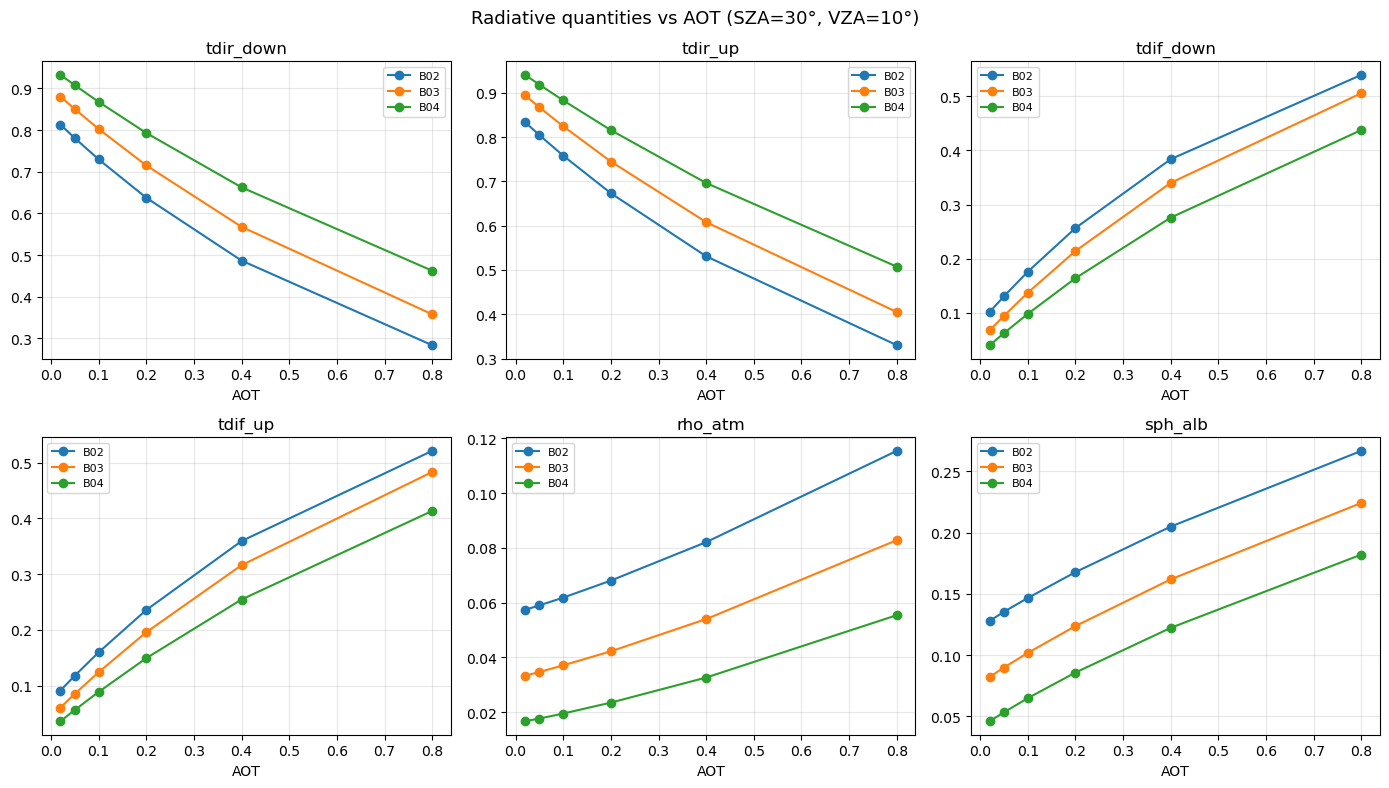

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
vars_to_plot = [
    "tdir_down", 
    "tdir_up", 
    "tdif_down", 
    "tdif_up", 
    "rho_atm", 
    "sph_alb"
]
colors = {S2Band.B02: "C0", S2Band.B03: "C1", S2Band.B04: "C2"}

for ax, var in zip(axes.flat, vars_to_plot):
    for band in BANDS:
        da = scene_sweep[band][var].squeeze()
        # squeeze out all dims except aot
        da = da.squeeze(drop=True)
        ax.plot(
            aot_values, 
            da.values, 
            marker="o", 
            label=band.id, 
            color=colors[band]
        )
    ax.set_title(var)
    ax.set_xlabel("AOT")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Radiative quantities vs AOT (SZA=30°, VZA=10°)", fontsize=13)
plt.tight_layout()
plt.show()

## 3.3 — Caching

Results can be cached to disk so that re-running the same configuration does not run the module core function.

In [6]:
import time
from adjeff.utils import CacheStore

cache = CacheStore("./adjeff_cache")

pipeline_cached = RadiativePipeline(
    atmo_config=atmo,
    geo_config=geo,
    spectral_config=spectral,
    remove_rayleigh=False,
    cache=cache,
)

# First run — computes and saves
t0 = time.perf_counter()
scene_c1 = pipeline_cached(ImageDict({band: xr.Dataset() for band in BANDS}))
t1 = time.perf_counter()
print(f"First run : {t1 - t0:.2f}s")

# Second run — loads from cache
t0 = time.perf_counter()
scene_c2 = pipeline_cached(ImageDict({band: xr.Dataset() for band in BANDS}))
t1 = time.perf_counter()
print(f"Cache hit : {t1 - t0:.2f}s")

First run : 0.53s
Cache hit : 0.16s


## 3.4 — Angular sweep: effect of SZA on transmittances

Here is another exemple where the effect of the Sun Zenith Angle on the computed direct downward transmittance is illustrated.

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.


Box(children=(FloatProgress(value=0.0, max=450000000.0), Label(value='')), layout=Layout(align_items='center',…

There is no current context to clear.


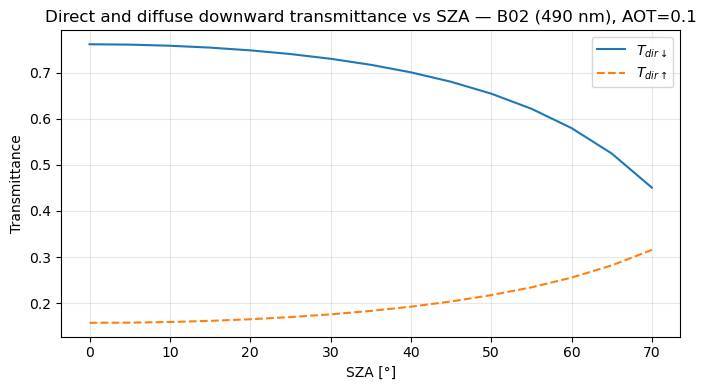

In [7]:
sza_values = np.arange(0.0, 75.0, 5.0)

geo_sza = GeoConfig(
    sza=xr.DataArray(sza_values, dims=["sza"]),
    vza=xr.DataArray([0.0], dims=["vza"]),
    saa=xr.DataArray([120.0], dims=["saa"]),
    vaa=xr.DataArray([120.0], dims=["vaa"]),
)

# Use a lighter setup: only tdir samplers (analytical, much faster)
from adjeff.modules.samplers import SmartgSampler_Tdir_down, SmartgSampler_Tdif_down
from adjeff.modules import Pipeline

pipeline_sza = Pipeline([
    SmartgSampler_Tdir_down(
        atmo_config=atmo,
        geo_config=geo_sza,
        spectral_config=SpectralConfig.from_bands([S2Band.B02]),
        remove_rayleigh=False,
    ),
    SmartgSampler_Tdif_down(
        atmo_config=atmo,
        geo_config=geo_sza,
        spectral_config=SpectralConfig.from_bands([S2Band.B02]),
        remove_rayleigh=False,
    ),
])

scene_sza = pipeline_sza(ImageDict({S2Band.B02: xr.Dataset()}))

tdir_down = scene_sza[S2Band.B02]["tdir_down"].squeeze()
tdif_down = scene_sza[S2Band.B02]["tdif_down"].squeeze()

plt.figure(figsize=(7, 4))
plt.plot(sza_values, tdir_down.values, label="$T_{dir\\downarrow}$")
plt.plot(sza_values, tdif_down.values, label="$T_{dir\\uparrow}$", linestyle="--")
plt.xlabel("SZA [°]")
plt.ylabel("Transmittance")
plt.title("Direct and diffuse downward transmittance vs SZA — B02 (490 nm), AOT=0.1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()